In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/Tec-IA-Proyectos-26/ObraSync_Datos_Alfa/refs/heads/main/DATOS/DATA_BASE_CLEAN.csv')

In [13]:
print("--- Columnas y tipos de datos ---")
df.info()

print("\n--- Primeras 5 filas del dataset ---")
df.head()

--- Columnas y tipos de datos ---
<class 'pandas.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   descripcion    629 non-null    str    
 1   marca          629 non-null    str    
 2   compra_total   629 non-null    float64
 3   ingreso_total  629 non-null    float64
 4   pendiente      629 non-null    float64
 5   estado         629 non-null    str    
 6   fecha          629 non-null    str    
 7   año            629 non-null    int64  
dtypes: float64(3), int64(1), str(4)
memory usage: 39.4 KB

--- Primeras 5 filas del dataset ---


,descripcion,marca,compra_total,ingreso_total,pendiente,estado,fecha,año
0,ESPATULA PINTOR LAMINADA CABO PLASTICO - 50 MM,BIASSONI,36.0,1.0,36.0,INCOMPLETO,2026-01-29,2026
1,AEROSOL SMART PAINT AA BLANCO BRILLANTE 350ML...,DOBLE A - AE,72.0,72.0,0.0,FULL,2026-01-29,2026
2,PANTALON CARGO DEL NORTE MUJER - PAMPERO VERDE...,PAMPERO,2.0,1.0,2.0,INCOMPLETO,2026-01-29,2026
3,REGULADOR GLP C/1 MAN. (PROP. Y OTROS),FERROLAN,15.0,15.0,0.0,FULL,2026-01-29,2026
4,AEROSOL USO GENERAL NEGRO MATE 250 GR,TEKBOND,60.0,1.0,60.0,INCOMPLETO,2026-01-29,2026


1. ANALISIS DESCRIPTIVO


In [14]:
print(df[['compra_total', 'ingreso_total', 'pendiente']].describe())

print("\n--- Distribución del Estado de los Pedidos ---")
print(df['estado'].value_counts())

       compra_total  ingreso_total    pendiente
count    629.000000     629.000000   629.000000
mean     312.937997     275.294118    37.745628
std      664.007013     602.637587   233.298391
min        1.000000       1.000000   -30.000000
25%       15.000000       6.000000     0.000000
50%       50.000000      30.000000     0.000000
75%      300.000000     250.000000     0.000000
max     6000.000000    5000.000000  3000.000000

--- Distribución del Estado de los Pedidos ---
estado
FULL          504
PARCIAL        63
INCOMPLETO     62
Name: count, dtype: int64


El dataset bajo estudio cuenta con un total de 629 registros (filas) y 8 variables (columnas), sin presentar valores nulos en ninguna de sus celdas.

A nivel cuantitativo, analizamos el comportamiento de las compras, los ingresos físicos del material y los saldos pendientes. A nivel cualitativo, se observa que la variable estado clasifica los registros (con categorías como FULL e INCOMPLETO). El marco temporal de los datos corresponde al año 2026.

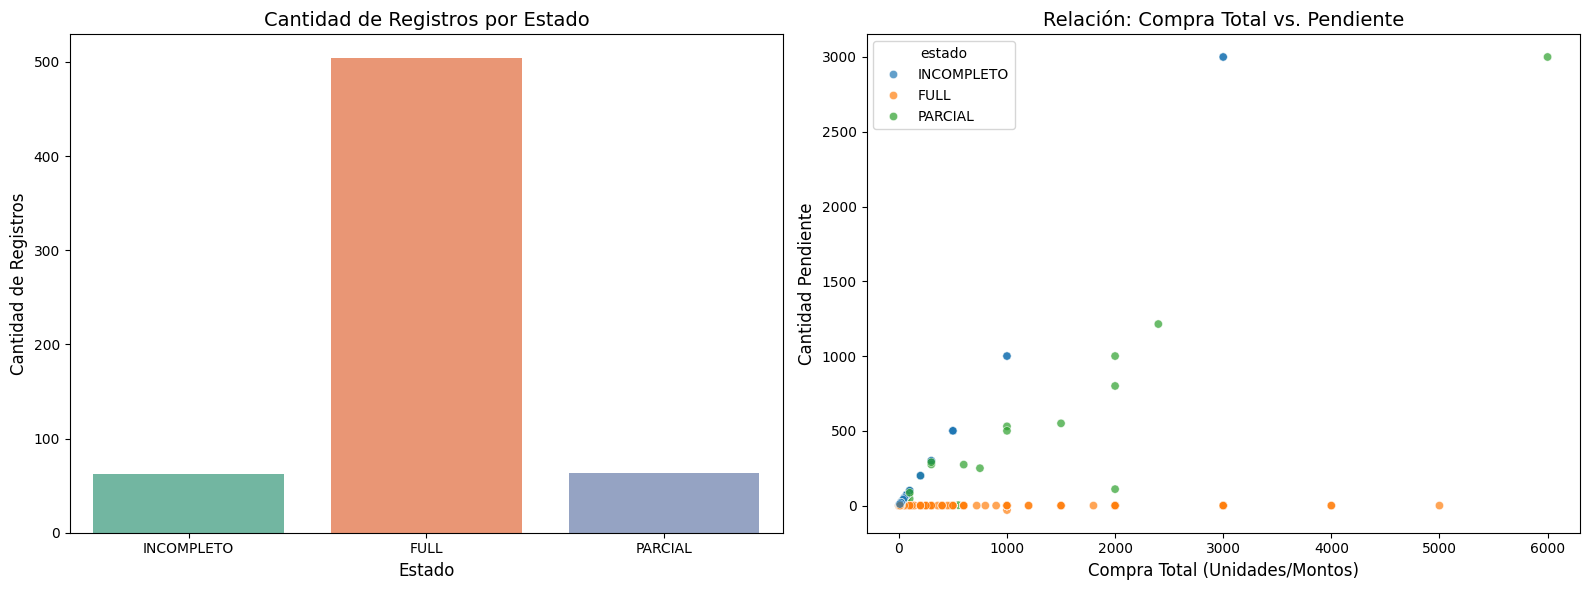

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución de los Estados (¿Cómo se reparten los pedidos?)
sns.countplot(data=df, x='estado', ax=axes[0], hue='estado', palette='Set2', legend=False)
axes[0].set_title('Cantidad de Registros por Estado', fontsize=14)
axes[0].set_xlabel('Estado', fontsize=12)
axes[0].set_ylabel('Cantidad de Registros', fontsize=12)

# Gráfico 2: Relación entre Compra Total y Pendiente (¿Dónde se concentran las deudas de stock?)
sns.scatterplot(data=df, x='compra_total', y='pendiente', hue='estado', alpha=0.7, ax=axes[1])
axes[1].set_title('Relación: Compra Total vs. Pendiente', fontsize=14)
axes[1].set_xlabel('Compra Total (Unidades/Montos)', fontsize=12)
axes[1].set_ylabel('Cantidad Pendiente', fontsize=12)

plt.tight_layout()
plt.show()

2. Detección de Patrones:

Concentración del Estado de Pedidos: A través del gráfico de barras, podemos observar cómo se distribuyen los materiales que ingresaron por completo (FULL) frente a aquellos que registran faltantes (INCOMPLETO), permitiendo identificar visualmente si el cuello de botella de la obra está en las entregas pendientes.

Comportamiento de la Pendiente: El gráfico de dispersión  muestra una relación lineal clara: a mayor volumen de compra_total, el saldo pendiente tiende a incrementarse proporcionalmente para los casos marcados como INCOMPLETO. Los puntos se agrupan marcadamente según su estado, lo que valida que la lógica de negocio está bien reflejada en el dataset (los estados FULL se mantienen sobre el eje cero de pendientes).

**Primeras Conclusiones:**

Consistencia de los Datos:

El dataset se encuentra completamente limpio en cuanto a estructura (601 registros homogéneos sin datos faltantes), lo que garantiza la confiabilidad para análisis posteriores.

Alerta Operativa:

Existe una proporción significativa de registros en estado INCOMPLETO (unidades compradas que aún no ingresaron a la obra). Esto expone la necesidad de ajustar el control de stock o la logística con los proveedores (como Biassoni, Tekbond, etc.) para evitar retrasos en las tareas de construcción.

Próximos Pasos:

Sobre la base de este análisis exploratorio, se propone profundizar en un análisis por marca o fecha para descubrir si las demoras y saldos pendientes están concentrados en proveedores específicos o si responden a un factor temporal (estacionalidad de entregas en meses particulares de 2026).